In [1]:
import experiments 

cwd appended to system path


In [2]:
data = experiments.load('results/lv_fvc_c.pkl')

In [24]:
eps = experiments.get_attr(data,'alpha_threshold',trunc = False,slice = -1)

In [ ]:
for k in eps.keys():
    print(f'Key: {k}. Mean threshold: {}')

{(32,): [np.float64(0.47565967415106164),
  np.float64(0.5210034697931513),
  np.float64(0.47694654528919556),
  np.float64(0.3955165273634243),
  np.float64(0.4830808148358049),
  np.float64(0.5956049002234398),
  np.float64(0.5231341516323375),
  np.float64(0.4454602265008001),
  np.float64(0.5354306379037979),
  np.float64(0.508772199834682)],
 (64,): [np.float64(0.3125966598570403),
  np.float64(0.29375692655646984),
  np.float64(0.26947581920298463),
  np.float64(0.2586632060566479),
  np.float64(0.34888809432163354),
  np.float64(0.2915250236526262),
  np.float64(0.4352855399863933),
  np.float64(0.39650996610155476),
  np.float64(0.3659363950185752),
  np.float64(0.35893219341104277)],
 (128,): [np.float64(0.27007775432956804),
  np.float64(0.1952941194365929),
  np.float64(0.31228452718756533),
  np.float64(0.23885926258224024),
  np.float64(0.23534096359261278),
  np.float64(0.22357279108899814),
  np.float64(0.21261154167408694),
  np.float64(0.3634392021442993),
  np.float64

In [ ]:
times[]

In [14]:
k = (2, None, 1.0)
for i in range(10):
    print(time[k][i])

[0.371288537979126, 0.955096960067749, 1.7023398876190186, 2.8101401329040527, 4.659989833831787, 7.266814708709717]
[0.36209774017333984, 0.9131152629852295, 1.6809332370758057, 2.7085676193237305, 4.405507326126099, 6.5934271812438965]
[0.34087657928466797, 1.3475947380065918, 6.637673616409302, 7.931940078735352, 9.735666513442993, 12.336387395858765]
[0.31395745277404785, 0.8658254146575928, 1.7350177764892578, 3.095477342605591, 5.2851221561431885, 8.209132194519043]
[0.3325035572052002, 0.8857860565185547, 1.720139503479004, 8.19083547592163, 10.444244384765625, 13.840581178665161]
[0.3517301082611084, 0.8790938854217529, 1.7750537395477295, 3.6500511169433594, 9.0266695022583, 11.823479652404785]
[0.3373270034790039, 0.9154596328735352, 1.824974536895752, 3.2242305278778076, 5.144930362701416, 12.105495691299438]
[0.35492467880249023, 0.9313085079193115, 1.698347568511963, 2.926284074783325, 4.764817476272583, 7.356518983840942]
[0.34107327461242676, 0.9196188449859619, 1.683476

In [4]:
experiments.time_series('results/lv_fvc_c.pkl')

Saved: results/lv_fvc_c_total_time.svg
Saved: results/lv_fvc_c_total_sims.svg
Saved: results/lv_fvc_c_log_hdpr_product.svg
Saved: results/lv_fvc_c_acceptance_rate.svg
Saved: results/lv_fvc_c_v_total_est.svg
Saved: results/lv_fvc_c_alpha_threshold.svg
Saved: results/lv_fvc_c_snr.svg
Saved: results/lv_fvc_c_batch_size.svg
Saved: results/lv_fvc_c_ESS.svg


FileNotFoundError: [Errno 2] No such file or directory: 'results/lv_constant_vs_results/lv_constant_pareto.svg'

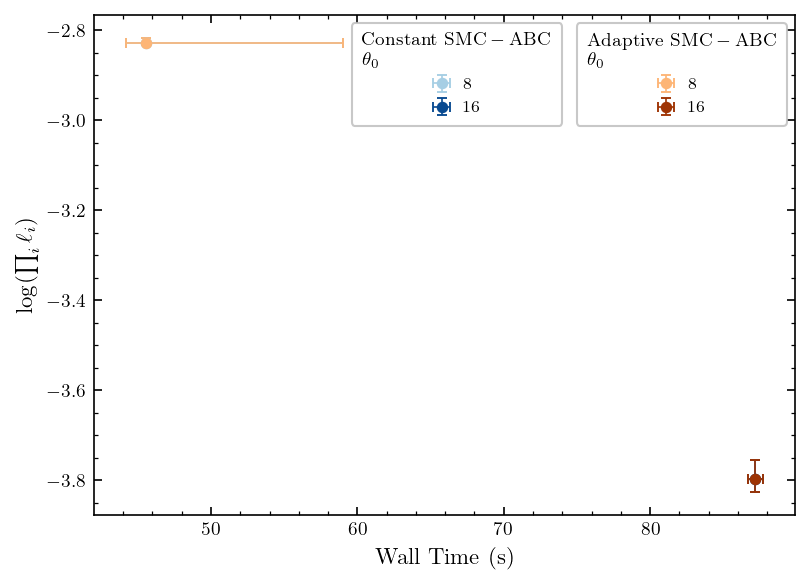

In [2]:
experiments.pareto_frontier('results/lv_constant.pkl','results/lv_constant.pkl')

In [14]:
f = 'results/lv_constant.pkl'
print(f[:-4])

results/lv_constant


In [12]:
results = experiments.load('results/lv_constant.pkl')
results[(8,)][0][0].keys()

dict_keys(['total_time', 'total_sims', 'log_hdpr_product', 'alpha_threshold', 'v_total_est', 'snr', 'acceptance_rate', 'batch_size', 'hdpr_marginal', 'ESS'])

In [8]:
total_time = experiments.get_attr(results,'total_time')
total_sims = experiments.get_attr(results,'total_sims')
hdpr = experiments.get_attr(results,'log_hdpr_product')
experiments.get_quantiles(total_time)

{(8,): array([[ 0.58730793,  1.59954607,  3.22105777,  5.43345118,  8.13391149,
         11.29425061, 15.18467736],
        [ 0.58813715,  1.6008451 ,  3.23492813,  5.49793077,  8.20573306,
         11.62483835, 15.68858099],
        [ 4.84493268,  6.0090766 ,  7.629637  ,  9.89063466, 12.76050663,
         16.16964674, 20.1156826 ]])}

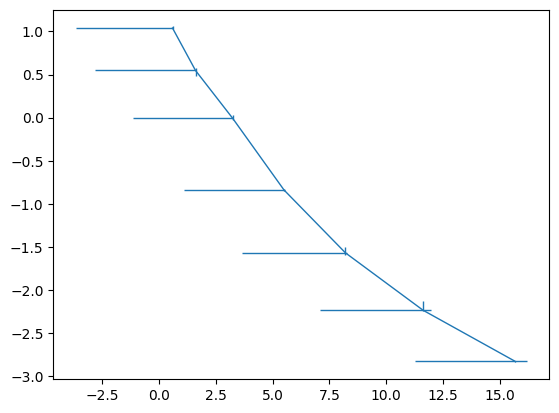

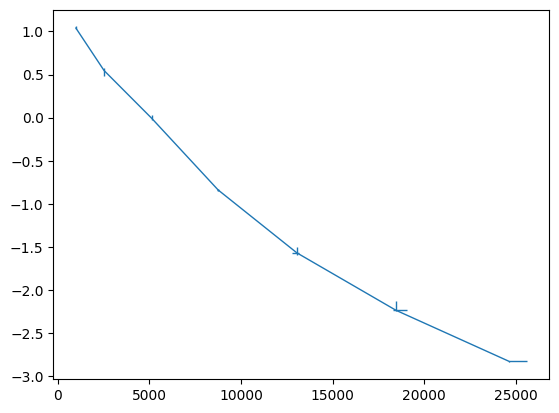

In [11]:
fa = experiments.plot_ts(total_time,hdpr)
fa2 = experiments.plot_ts(total_sims,hdpr)

In [ ]:
def retro_stop(results, stop_func):
    """stop_func returns True on the last generation to INCLUDE."""
    results_new = {}
    for param, replicates in results.items():
        results_new[param] = []
        for replicate in replicates:
            truncated = []
            for gen_idx, gen_dict in enumerate(replicate):
                truncated.append(gen_dict)
                if stop_func(gen_dict, gen_idx):
                    break          # include this gen, then stop
            results_new[param].append(truncated)
    return results_new

In [ ]:
def retro_stop(results, stop_func):
    """
    Retroactively apply a stopping criterion to a results dict.

    Parameters
    ----------
    results   : dict — the original nested results structure
    stop_func : callable — signature: stop_func(generation_dict, gen_idx) -> bool
                Returns True when the run *should have stopped* BEFORE
                recording this generation (i.e. this gen is excluded).
                Alternatively, return True to mean "stop AFTER this gen"
                — just be consistent with your convention (see note below).

    Returns
    -------
    results_new : dict with the same structure but each replicate truncated
                  to the first generation where stop_func triggered.
    """
    results_new = {}

    for param, replicates in results.items():
        results_new[param] = []

        for replicate in replicates:
            truncated = []
            for gen_idx, gen_dict in enumerate(replicate):
                if stop_func(gen_dict, gen_idx):
                    break          # stop BEFORE including this generation
                truncated.append(gen_dict)

            # Guard: always keep at least generation 0
            if not truncated:
                truncated = [replicate[0]]

            results_new[param].append(truncated)

    return results_new

## Very different testing: Are my models right?

In [111]:
import smc_abc_schemes as schemes
import transcriptional_dynamics as td
import lotka_volterra as lv

